In [1]:
import os
import pickle
from pathlib import Path
import numpy as np

# import required module
import sys

# append the path of the
# parent directory
sys.path.append("..")
 
# import method from sibling 
# module
from data_utils import save_samples_as_cifs, save_reconstructions_as_cifs, visualize_trajectory
from utils import retrieve_artifacts_by_name


import env

# Load environment variables
env.load_envs()

# Set the cwd to the project root
PROJECT_ROOT: Path = Path(env.get_env("PROJECT_ROOT"))
assert (
    PROJECT_ROOT.exists()
), "You must configure the PROJECT_ROOT environment variable in a .env file!"

os.chdir(PROJECT_ROOT)

cwd = os.getcwd()

c:\Users\dglav\Anaconda3\envs\thesis\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
experiment_name = "sampe_zdivae_small"

# artifact_files = retrieve_artifacts_by_name(experiment_name, artifact_type='dataset', project='zeogen', entity='glafk')

# for file in artifact_files:
#     if "samples" in file:
#         with open(file, "rb") as f:
#             samples = pickle.load(f)


samples_file = "samples-sample_zdivae_small.pickle"

with open(f"./samples/{samples_file}", "rb") as f:
    samples = pickle.load(f)



In [6]:
print(len(samples))
print(samples[0].keys())

19
dict_keys(['zd', 'zy', 'num_atoms', 'lengths', 'angles', 'frac_coords', 'atom_types', 'domains', 'norm_hoas', 'pred_hoas', 'pred_norm_hoas', 'pred_domains', 'is_traj', 'all_frac_coords', 'all_atom_types'])


In [17]:
# make a dict with all zd embeddings and and predicted domains
zd_domains = []
for sample in samples:
    for zd, domain in zip(sample["zd"], sample["domains"]):
        zd_domains.extend([(zd, domain)])

print(zd_domains)
print(len(zd_domains))

[(array([-1.1619930e+00,  4.8426503e-01, -2.6065910e-01, -1.1216664e-01,
       -4.6259654e-01, -7.9077400e-02,  4.9781841e-01,  5.4258037e-01,
        9.7161633e-01,  1.5382484e-01,  4.2846555e-01,  1.3197875e-01,
       -7.9650313e-02,  4.4941348e-01, -8.5810459e-01, -5.5424869e-03,
        2.6695043e-01,  2.1326755e-01,  1.9636387e-01,  1.6624201e-02,
       -7.7619031e-02,  4.2491090e-01, -1.8821824e-01,  3.5700941e-01,
       -2.4356492e-01, -2.2839665e-02,  3.1137705e-01,  8.2754546e-01,
       -6.6782677e-01,  5.5902386e-01,  3.9566058e-01, -4.7334266e-01,
        5.2101690e-01,  4.7121879e-01, -6.7207128e-01, -2.8448895e-02,
       -7.2304857e-01,  5.9858337e-04, -6.5601796e-01, -9.3776956e-02,
       -5.9401989e-03,  4.6562156e-01, -1.1332387e-01,  1.8943363e-01,
       -2.7902722e-02,  2.4556279e-02, -3.2859758e-01,  3.1574696e-01,
       -1.4184570e-01,  9.2191577e-02,  3.2319215e-01,  7.3835075e-01,
       -7.0668685e-01, -1.5706927e-01,  2.3085359e-01,  5.3353041e-01,
    

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from collections import defaultdict

# Define method for computing the t-SNE of the latent space and plotting
def plot_tsne(embeddings_list):
    # Extract embeddings and labels
    embeddings = np.array([item[0] for item in embeddings_list])
    print(embeddings)
    labels = np.array([item[1] for item in embeddings_list])

    # Perform t-SNE dimensionality reduction
    tsne = TSNE(n_components=2, random_state=42)
    transformed_embeddings = tsne.fit_transform(embeddings)

    # Assign unique colors to each class
    unique_labels = np.unique(labels)
    color_map = plt.cm.get_cmap("tab10", len(unique_labels))
    label_to_color = {label: color_map(i) for i, label in enumerate(unique_labels)}

    # Plot the t-SNE results
    plt.figure(figsize=(8, 6))
    for label in unique_labels:
        idxs = labels == label
        plt.scatter(
            transformed_embeddings[idxs, 0], 
            transformed_embeddings[idxs, 1], 
            color=label_to_color[label], 
            label=label, 
            alpha=0.7
        )

    plt.legend(title="Classes")
    plt.title("t-SNE Visualization of Embeddings")
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.show()


In [18]:
def compute_variance_per_class(embeddings_list):
    """
    Computes the variance of embeddings per class.

    :param embeddings_list: List of tuples (embedding, class_label)
    :return: Dictionary {class_label: variance_vector}
    """
    # Group embeddings by class
    class_embeddings = defaultdict(list)
    for embedding, label in embeddings_list:
        class_embeddings[label].append(embedding)

    # Convert to numpy arrays and compute variance per class
    class_variances = {}
    for label, embeddings in class_embeddings.items():
        embeddings_array = np.array(embeddings)  # Shape: (num_samples, embedding_dim)
        variance_vector = np.var(embeddings_array, axis=0)  # Variance along each dimension
        class_variances[label] = variance_vector

    return class_variances

[[-1.161993    0.48426503 -0.2606591  ...  0.22575898 -0.11842075
  -1.1921877 ]
 [-1.161993    0.48426503 -0.2606591  ...  0.22575898 -0.11842075
  -1.1921877 ]
 [-1.161993    0.48426503 -0.2606591  ...  0.22575898 -0.11842075
  -1.1921877 ]
 ...
 [-0.39082098  0.5038171  -0.03369318 ...  0.69833136 -0.06091675
  -0.7342788 ]
 [-0.39082098  0.5038171  -0.03369318 ...  0.69833136 -0.06091675
  -0.7342788 ]
 [-0.39082098  0.5038171  -0.03369318 ...  0.69833136 -0.06091675
  -0.7342788 ]]


C:\Users\dglav\AppData\Local\Temp\ipykernel_29840\873814851.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color_map = plt.cm.get_cmap("tab10", len(unique_labels))


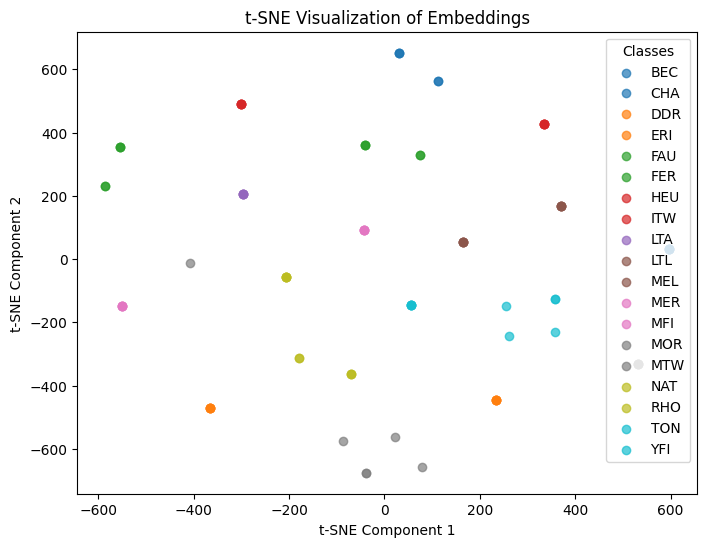

In [16]:
plot_tsne(zd_domains)

In [19]:
variance_per_class = compute_variance_per_class(zd_domains)
for class_label, variance in variance_per_class.items():
    print(f"Variance for {class_label}: {variance}")

Variance for YFI: [0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 8.8817842e-16
 0.0000000e+00 0.0000000e+00 0.0000000e+00 3.5527137e-15 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 2.2204460e-16 0.0000000e+00 0.0000000e+00
 0.0000000e+00 8.8817842e-16 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 8.8817842e-16 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 2.2204460e-16 0.